# 노트북 12. Embedding

> Phase 4 — 지식 확장: 외부 문서를 활용하는 법

텍스트를 숫자 벡터로 바꾸면, '의미적으로 비슷한 것'을 수학적으로 찾을 수 있습니다.
이것이 다음 노트북에서 배울 RAG(검색 증강 생성)의 기초 기술입니다.

**학습 목표**
- 임베딩의 원리와 벡터 공간의 의미를 이해한다
- Gemini Embedding API를 google-genai와 LangChain 두 방식으로 사용할 수 있다
- Cosine Similarity를 직접 구현하고 유사도 매트릭스를 시각화할 수 있다
- Chroma와 FAISS 벡터 스토어를 사용하고 차이를 비교할 수 있다

**구성**
| Part | 내용 | 형태 |
|------|------|------|
| Part 1 — 이론 | 임베딩 원리 + 유사도 + 벡터 스토어 | 읽고 실행 |
| Part 2 — 실습 | Gemini 임베딩 + Chroma + FAISS | 직접 작성 |
| Part 3 — 챌린지 | 한국어 유사도 매트릭스 시각화 | 강사와 함께 |

In [ ]:
# 환경 설정 — 이 셀을 먼저 실행하세요
!pip install -q google-genai langchain-google-genai chromadb faiss-cpu numpy matplotlib langchain-community

import os
import numpy as np
from google import genai

# API 키 설정 (Colab 환경 기준)
from google.colab import userdata
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=GEMINI_API_KEY)

EMBEDDING_MODEL = "gemini-embedding-001"

print("환경 설정 완료")

환경 설정 완료


---

# Part 1 — 이론

개념을 마크다운 설명과 실행 가능한 코드 예시로 배웁니다.
읽고 실행하면서 따라와 주세요.

## 1.1 임베딩이란?

**Embedding**(임베딩)은 텍스트를 고차원 숫자 벡터로 변환하는 기술입니다.

핵심 아이디어: **의미가 비슷한 텍스트는 벡터 공간에서 가까이 위치합니다.**

```
"서울의 날씨"  →  [0.12, -0.34, 0.56, ...] (768차원)
"수도 기온"    →  [0.11, -0.32, 0.55, ...] (768차원)  ← 벡터가 유사!
"파이썬 문법"  →  [0.78, 0.21, -0.43, ...] (768차원)  ← 벡터가 다름
```

단어가 다르더라도 의미가 비슷하면 벡터가 유사합니다.
이 성질을 이용하면:
- "질문과 가장 관련 있는 문서 찾기" (RAG의 Retrieve)
- "유사한 상품 추천"
- "중복 문서 탐지"

등의 작업이 가능합니다.

## 1.2 Gemini Embedding API (google-genai)

Gemini는 `gemini-embedding-001` 모델을 제공합니다.
768차원 벡터를 반환하며, 한국어도 지원합니다.

아래 코드는 google-genai SDK로 텍스트를 임베딩하는 기본 방법을 보여줍니다.

In [ ]:
# google-genai로 단일 텍스트 임베딩
result = client.models.embed_content(
    model=EMBEDDING_MODEL,
    contents="서울의 날씨가 좋습니다",
)

embedding = result.embeddings[0].values

print(f"모델: {EMBEDDING_MODEL}")
print(f"차원: {len(embedding)}")
print(f"처음 5개 값: {embedding[:5]}")
print(f"타입: {type(embedding)}")

모델: gemini-embedding-001
차원: 3072
처음 5개 값: [-0.017377792, -0.0090955375, 0.0076257004, -0.07365656, -0.0018142757]
타입: <class 'list'>


In [ ]:
# 여러 텍스트를 한 번에 임베딩 (배치)
texts = [
    "서울의 날씨가 좋습니다",
    "수도 기온이 따뜻합니다",
    "파이썬 리스트 컴프리헨션",
]

result = client.models.embed_content(
    model=EMBEDDING_MODEL,
    contents=texts,
)

print(f"입력 텍스트: {len(texts)}개")
print(f"반환 임베딩: {len(result.embeddings)}개")
for i, emb in enumerate(result.embeddings):
    print(f"  [{i}] {texts[i][:20]:20s} → 차원: {len(emb.values)}")

입력 텍스트: 3개
반환 임베딩: 3개
  [0] 서울의 날씨가 좋습니다         → 차원: 3072
  [1] 수도 기온이 따뜻합니다         → 차원: 3072
  [2] 파이썬 리스트 컴프리헨션        → 차원: 3072


> `embed_content()`는 `contents`에 문자열 하나 또는 리스트를 전달할 수 있습니다.
> 리스트를 전달하면 한 번의 API 호출로 여러 텍스트를 임베딩합니다 (배치 처리).

### task_type: 용도별 임베딩

Gemini Embedding API는 `config`에 `task_type`을 지정하여 용도에 맞는 임베딩을 생성할 수 있습니다.

| task_type | 용도 |
|-----------|------|
| `RETRIEVAL_QUERY` | 검색 질의 임베딩 |
| `RETRIEVAL_DOCUMENT` | 저장할 문서 임베딩 |
| `SEMANTIC_SIMILARITY` | 문장 유사도 비교 |
| `CLASSIFICATION` | 텍스트 분류 |
| `CLUSTERING` | 클러스터링 |

> 같은 텍스트라도 task_type에 따라 미세하게 다른 벡터가 생성됩니다.
> RAG에서는 문서 저장 시 `RETRIEVAL_DOCUMENT`, 검색 시 `RETRIEVAL_QUERY`를 사용하면
> 검색 정확도가 향상될 수 있습니다.

In [ ]:
from google.genai import types

text = "서울의 날씨가 좋습니다"

# 검색 질의용
result_query = client.models.embed_content(
    model=EMBEDDING_MODEL,
    contents=text,
    config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY"),
)

# 문서 저장용
result_doc = client.models.embed_content(
    model=EMBEDDING_MODEL,
    contents=text,
    config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT"),
)

vec_q = np.array(result_query.embeddings[0].values)
vec_d = np.array(result_doc.embeddings[0].values)

sim = np.dot(vec_q, vec_d) / (np.linalg.norm(vec_q) * np.linalg.norm(vec_d))

print(f"같은 텍스트, 다른 task_type")
print(f"  RETRIEVAL_QUERY    처음 3값: {vec_q[:3].round(4)}")
print(f"  RETRIEVAL_DOCUMENT 처음 3값: {vec_d[:3].round(4)}")
print(f"  두 벡터 유사도: {sim:.4f} (1.0이 아닐 수 있음)")

같은 텍스트, 다른 task_type
  RETRIEVAL_QUERY    처음 3값: [-0.0174 -0.0091  0.0076]
  RETRIEVAL_DOCUMENT 처음 3값: [-0.0287  0.0036  0.0188]
  두 벡터 유사도: 0.8655 (1.0이 아닐 수 있음)


## 1.3 LangChain 임베딩

LangChain은 `GoogleGenerativeAIEmbeddings` 클래스를 제공합니다.
인터페이스가 통일되어 있어, 나중에 벡터 스토어와 쉽게 연결할 수 있습니다.

| 메서드 | 용도 | 입력 |
|--------|------|------|
| `embed_query()` | 검색 질의 임베딩 | 문자열 1개 |
| `embed_documents()` | 문서 임베딩 (배치) | 문자열 리스트 |

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# LangChain 임베딩 모델 초기화
embeddings_model = GoogleGenerativeAIEmbeddings(
    model=f"models/{EMBEDDING_MODEL}",
    google_api_key=GEMINI_API_KEY,
)

# 단일 질의 임베딩
query_emb = embeddings_model.embed_query("서울의 날씨가 좋습니다")
print(f"embed_query 결과: 차원 {len(query_emb)}")

# 문서 배치 임베딩
doc_embs = embeddings_model.embed_documents([
    "서울의 날씨가 좋습니다",
    "파이썬 리스트 컴프리헨션",
])
print(f"embed_documents 결과: {len(doc_embs)}개, 각 차원 {len(doc_embs[0])}")

embed_query 결과: 차원 3072
embed_documents 결과: 2개, 각 차원 3072


> **embed_query vs embed_documents**: 일부 임베딩 모델은 질의용과 문서용 임베딩을 다르게 생성합니다.
> 벡터 스토어와의 호환을 위해 관례적으로 구분하여 사용합니다.

## 1.4 Cosine Similarity

두 벡터가 얼마나 비슷한지를 측정하는 가장 대표적인 방법이
**Cosine Similarity**(코사인 유사도)입니다.

```
cosine_similarity(A, B) = (A · B) / (||A|| × ||B||)
```

| 값 | 의미 |
|----|------|
| 1.0 | 완전히 같은 방향 (매우 유사) |
| 0.0 | 직교 (관련 없음) |
| -1.0 | 반대 방향 (매우 다름) |

> 벡터의 크기(길이)가 아닌 **방향**만 비교합니다.
> 긴 문장이든 짧은 문장이든, 의미가 같으면 유사도가 높습니다.

아래 코드는 numpy로 코사인 유사도를 직접 구현합니다.

In [ ]:
# 코사인 유사도 직접 구현
def cosine_similarity(a, b):
    """두 벡터의 코사인 유사도를 계산합니다."""
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# 3개 문장 임베딩
sentences = [
    "서울의 날씨가 좋습니다",
    "수도 기온이 따뜻합니다",
    "파이썬 리스트 컴프리헨션",
]

result = client.models.embed_content(
    model=EMBEDDING_MODEL,
    contents=sentences,
)
vectors = [emb.values for emb in result.embeddings]

# 모든 쌍의 유사도 계산
print("코사인 유사도:")
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        sim = cosine_similarity(vectors[i], vectors[j])
        print(f"  '{sentences[i]}' vs '{sentences[j]}': {sim:.4f}")

코사인 유사도:
  '서울의 날씨가 좋습니다' vs '수도 기온이 따뜻합니다': 0.7509
  '서울의 날씨가 좋습니다' vs '파이썬 리스트 컴프리헨션': 0.4980
  '수도 기온이 따뜻합니다' vs '파이썬 리스트 컴프리헨션': 0.4907


### 출력 차원 조절

`output_dimensionality` 파라미터로 임베딩 벡터의 차원을 줄일 수 있습니다.

차원을 줄이면 저장 공간과 검색 속도가 개선되지만, 정확도가 약간 감소할 수 있습니다.

```python
result = client.models.embed_content(
    model=EMBEDDING_MODEL,
    contents="텍스트",
    config=types.EmbedContentConfig(output_dimensionality=256),
)
# 결과: 256차원 벡터 (기본 768차원 대비 1/3 크기)
```

> 대규모 데이터에서 비용과 속도가 중요하다면, 256 또는 512 차원으로 줄여서
> 정확도 손실이 허용 범위 내인지 테스트해보세요.

> "서울의 날씨" vs "수도 기온"은 단어가 다르지만 유사도가 높고,
> "파이썬 리스트 컴프리헨션"과는 유사도가 낮습니다.
> 임베딩이 단어가 아닌 **의미**를 포착하고 있음을 확인할 수 있습니다.

## 1.5 유사도 매트릭스 시각화

여러 문장 간의 유사도를 한눈에 파악하려면 매트릭스를 히트맵으로 시각화하는 것이 효과적입니다.

아래 코드는 6개 문장의 유사도 매트릭스를 생성하고 시각화합니다.

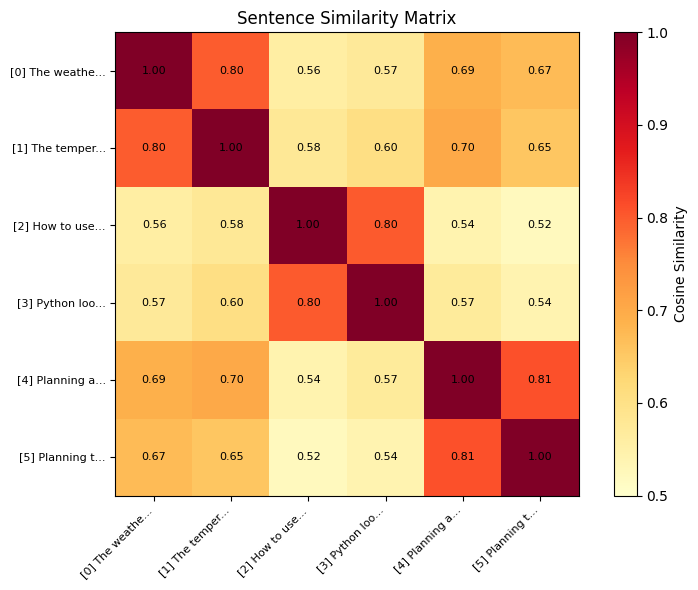

[0-1] 날씨 / [2-3] 프로그래밍 / [4-5] 여행


In [ ]:
import matplotlib.pyplot as plt

# 6개 문장 — 3개 주제 x 2개 표현
sentences_6 = [
    "The weather is clear in Seoul today",              # Weather 1
    "The temperature in the Seoul metro area is 15°C",  # Weather 2
    "How to use Python for loops",                      # Programming 1
    "Python loop syntax guide",                         # Programming 2
    "Planning a trip to Busan this weekend",             # Travel 1
    "Planning to visit Haeundae this holiday",           # Travel 2
]

result = client.models.embed_content(
    model=EMBEDDING_MODEL,
    contents=sentences_6,
    config=types.EmbedContentConfig(output_dimensionality=256)
)
vecs = np.array([emb.values for emb in result.embeddings])

# 유사도 매트릭스 계산
# 정규화 후 내적 = 코사인 유사도
norms = np.linalg.norm(vecs, axis=1, keepdims=True)
vecs_normalized = vecs / norms
sim_matrix = vecs_normalized @ vecs_normalized.T

# 히트맵 시각화
plt.figure(figsize=(8, 6))
plt.imshow(sim_matrix, cmap="YlOrRd", vmin=0.5, vmax=1.0)
plt.colorbar(label="Cosine Similarity")

# 라벨 — 한글 깨짐 방지를 위해 인덱스 사용
labels = [f"[{i}] {s[:10]}..." for i, s in enumerate(sentences_6)]
plt.xticks(range(6), labels, rotation=45, ha="right", fontsize=8)
plt.yticks(range(6), labels, fontsize=8)

# 값 표시
for i in range(6):
    for j in range(6):
        plt.text(j, i, f"{sim_matrix[i][j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Sentence Similarity Matrix")
plt.tight_layout()
plt.show()

# 주제 확인
print("[0-1] 날씨 / [2-3] 프로그래밍 / [4-5] 여행")

> 같은 주제의 문장 쌍(0-1, 2-3, 4-5)이 높은 유사도를 보이고,
> 다른 주제 간에는 상대적으로 낮은 유사도를 보입니다.
> 이 성질이 RAG의 검색(Retrieve)을 가능하게 합니다.

In [ ]:
# numpy로 벡터화된 코사인 유사도 — 대량 계산에 효율적
def cosine_similarity_matrix(vectors):
    """벡터 리스트로 NxN 유사도 매트릭스를 한번에 계산합니다."""
    vecs = np.array(vectors)
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    normalized = vecs / norms
    return normalized @ normalized.T  # NxN 행렬곱

# 테스트: 위에서 만든 3개 벡터
result = client.models.embed_content(
    model=EMBEDDING_MODEL,
    contents=["서울의 날씨", "수도 기온", "파이썬 문법"],
)

vecs = [emb.values for emb in result.embeddings]
matrix = cosine_similarity_matrix(vecs)

print("유사도 매트릭스 (벡터화 계산):")
print(np.round(matrix, 4))
print("\n반복문 대비 수백~수천 배 빠릅니다 (대규모 데이터에서)")

유사도 매트릭스 (벡터화 계산):
[[1.     0.6801 0.5758]
 [0.6801 1.     0.5213]
 [0.5758 0.5213 1.    ]]

반복문 대비 수백~수천 배 빠릅니다 (대규모 데이터에서)


## 1.6 벡터 스토어란?

**Vector Store**(벡터 스토어)는 임베딩 벡터를 저장하고,
질의 벡터와 가장 유사한 벡터를 빠르게 검색하는 특수 데이터베이스입니다.

```
1. 문서들을 임베딩하여 벡터 스토어에 저장
2. 사용자 질문을 임베딩
3. 질문 벡터와 가장 유사한 문서 벡터 N개를 검색
4. 검색된 문서를 LLM에 전달하여 답변 생성 (= RAG)
```

| 벡터 스토어 | 개발사 | 특징 | 적합한 경우 |
|-------------|--------|------|------------|
| **Chroma** | Chroma Inc. | SQLite 백엔드, 메타데이터 필터링, 서버 모드 | 프로토타입~중규모 |
| **FAISS** | Meta | 인메모리, 대규모 고속 검색 | 대규모 프로덕션 |
| Pinecone | Pinecone | 매니지드 클라우드 서비스 | 서버리스 프로덕션 |
| Weaviate | Weaviate | 하이브리드 검색 (벡터+키워드) | 복합 검색 |

## 1.7 Chroma

**Chroma**는 Python 네이티브 벡터 스토어로, 설치가 간편하고
SQLite 백엔드로 영속성을 지원합니다.

아래 코드는 Chroma에 문서를 저장하고 검색하는 기본 흐름을 보여줍니다.

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma

# LangChain 임베딩 모델
embedding_func = GoogleGenerativeAIEmbeddings(
    model=f"models/{EMBEDDING_MODEL}",
    google_api_key=GEMINI_API_KEY,
)

# 샘플 문서 — 한국 도시 소개
documents = [
    Document(page_content="서울은 대한민국의 수도이며 인구 약 1000만 명이 거주합니다.", metadata={"city": "서울"}),
    Document(page_content="부산은 대한민국 제2의 도시로 해운대 해수욕장이 유명합니다.", metadata={"city": "부산"}),
    Document(page_content="제주도는 화산섬으로 한라산과 독특한 자연환경을 가지고 있습니다.", metadata={"city": "제주"}),
    Document(page_content="경주는 신라의 수도였으며 불국사와 석굴암이 있는 역사 도시입니다.", metadata={"city": "경주"}),
    Document(page_content="강릉은 동해안에 위치하며 커피 거리와 경포대로 유명합니다.", metadata={"city": "강릉"}),
    Document(page_content="태안은 서해안에 위치하며 갯벌과 해수욕장으로 유명합니다.", metadata={"city": "태안"}),
    Document(page_content="전주는 한옥마을과 비빔밥으로 유명한 전통 문화 도시입니다.", metadata={"city": "전주"}),
]

# Chroma에 문서 저장 (인메모리)
chroma_db = Chroma.from_documents(
    documents=documents,
    embedding=embedding_func,
    collection_name="korean_cities",
)

print(f"Chroma에 {len(documents)}개 문서 저장 완료")
print(f"컬렉션: {chroma_db._collection.name}")

Chroma에 7개 문서 저장 완료
컬렉션: korean_cities


In [ ]:
# 유사도 검색 — 질문과 가장 관련 있는 문서 찾기
query = "바다가 있는 관광지를 추천해주세요"

results = chroma_db.similarity_search_with_score(query, k=3)

print(f"질의: '{query}'\n")
print("=== 검색 결과 (상위 3개) ===")
for doc, score in results:
    print(f"  [{doc.metadata['city']}] (거리: {score:.4f})")
    print(f"    {doc.page_content}")

질의: '바다가 있는 관광지를 추천해주세요'

=== 검색 결과 (상위 3개) ===
  [태안] (거리: 0.6045)
    태안은 서해안에 위치하며 갯벌과 해수욕장으로 유명합니다.
  [강릉] (거리: 0.6301)
    강릉은 동해안에 위치하며 커피 거리와 경포대로 유명합니다.
  [강릉] (거리: 0.6301)
    강릉은 동해안에 위치하며 커피 거리와 경포대로 유명합니다.


> **score의 의미**: Chroma의 `similarity_search_with_score`는 **거리**(distance)를 반환합니다.
> 값이 **작을수록** 더 유사합니다 (유사도와 반대).
> 기본 거리 함수는 L2(유클리드 거리)입니다.

In [ ]:
# 메타데이터 필터링 — Chroma의 강점
# 특정 도시만 검색하거나, 조건으로 필터링 가능

results_filtered = chroma_db.similarity_search(
    "유명한 관광지",
    k=2,
    filter={"city": {"$in": ["부산", "제주", "경주"]}},  # 3개 도시로 제한
)

print("메타데이터 필터: city in [부산, 제주, 경주]\n")
for doc in results_filtered:
    print(f"  [{doc.metadata['city']}] {doc.page_content}")

메타데이터 필터: city in [부산, 제주, 경주]

  [부산] 부산은 대한민국 제2의 도시로 해운대 해수욕장이 유명합니다.
  [부산] 부산은 대한민국 제2의 도시로 해운대 해수욕장이 유명합니다.


### Chroma 영속 저장

Chroma는 `persist_directory`를 지정하면 SQLite 파일에 자동 저장됩니다.
프로세스를 재시작해도 데이터가 유지됩니다.

```python
# 영속 저장
chroma_persistent = Chroma.from_documents(
    documents=documents,
    embedding=embedding_func,
    persist_directory="./chroma_db",  # 이 디렉토리에 저장
    collection_name="my_docs",
)

# 재로딩 (프로세스 재시작 후)
chroma_loaded = Chroma(
    persist_directory="./chroma_db",
    embedding_function=embedding_func,
    collection_name="my_docs",
)
```

> FAISS는 `save_local()`/`load_local()`을 직접 호출해야 하지만,
> Chroma는 `persist_directory`만 지정하면 자동으로 영속화됩니다.

## 1.8 FAISS

**FAISS**(Facebook AI Similarity Search)는 Meta가 개발한
고성능 벡터 검색 라이브러리입니다.

| 특징 | Chroma | FAISS |
|------|--------|-------|
| 저장 방식 | SQLite (영속) | 인메모리 (파일 저장 별도) |
| 메타데이터 필터 | 지원 | 미지원 (별도 구현) |
| 검색 속도 | 보통 | 빠름 (대규모 데이터) |
| 설치 | `pip install chromadb` | `pip install faiss-cpu` |

아래 코드는 동일한 데이터를 FAISS에 저장하고 검색합니다.

In [ ]:
from langchain_community.vectorstores import FAISS

# 동일한 문서를 FAISS에 저장
faiss_db = FAISS.from_documents(
    documents=documents,
    embedding=embedding_func,
)

print(f"FAISS에 {len(documents)}개 문서 저장 완료")

FAISS에 7개 문서 저장 완료


In [ ]:
# FAISS 유사도 검색 — 동일한 질의
query = "바다가 있는 관광지를 추천해주세요"

results_faiss = faiss_db.similarity_search_with_score(query, k=3)

print(f"질의: '{query}'\n")
print("=== FAISS 검색 결과 (상위 3개) ===")
for doc, score in results_faiss:
    print(f"  [{doc.metadata['city']}] (거리: {score:.4f})")
    print(f"    {doc.page_content}")

질의: '바다가 있는 관광지를 추천해주세요'

=== FAISS 검색 결과 (상위 3개) ===
  [태안] (거리: 0.6037)
    태안은 서해안에 위치하며 갯벌과 해수욕장으로 유명합니다.
  [강릉] (거리: 0.6285)
    강릉은 동해안에 위치하며 커피 거리와 경포대로 유명합니다.
  [부산] (거리: 0.6591)
    부산은 대한민국 제2의 도시로 해운대 해수욕장이 유명합니다.


> Chroma와 FAISS 모두 LangChain의 `VectorStore` 인터페이스를 따르므로,
> `similarity_search()`, `similarity_search_with_score()` 등
> 동일한 메서드를 사용합니다. 벡터 스토어를 교체해도 코드 변경이 최소화됩니다.

## 1.9 FAISS 영속화

FAISS는 인메모리이므로, 프로세스가 종료되면 데이터가 사라집니다.
`save_local()` / `load_local()`로 파일에 저장하고 복원할 수 있습니다.

In [ ]:
# FAISS 인덱스를 파일에 저장
faiss_db.save_local("faiss_cities_index")
print("FAISS 인덱스 저장 완료")

# 저장된 파일 확인
import os
for f in os.listdir("faiss_cities_index"):
    size = os.path.getsize(f"faiss_cities_index/{f}")
    print(f"  {f}: {size:,} bytes")

# 파일에서 복원
faiss_loaded = FAISS.load_local(
    "faiss_cities_index",
    embedding_func,
    allow_dangerous_deserialization=True,  # pickle 역직렬화 허용
)

# 복원된 인덱스로 검색
result = faiss_loaded.similarity_search("역사 유적지", k=1)
print(f"\n복원 후 검색: [{result[0].metadata['city']}] {result[0].page_content}")

FAISS 인덱스 저장 완료
  index.faiss: 86,061 bytes
  index.pkl: 1,584 bytes

복원 후 검색: [경주] 경주는 신라의 수도였으며 불국사와 석굴암이 있는 역사 도시입니다.


> `allow_dangerous_deserialization=True`는 pickle 파일의 역직렬화를 허용합니다.
> 신뢰할 수 없는 소스의 파일은 로드하지 않도록 주의하세요.

## 1.10 Chroma vs FAISS 성능 비교

동일한 데이터로 Chroma와 FAISS의 검색 속도를 비교합니다.

In [ ]:
import time

# 검색 속도 비교
test_queries = [
    "대한민국의 수도는 어디인가요",
    "해수욕장이 유명한 도시",
    "전통 음식으로 유명한 곳",
    "자연환경이 아름다운 섬",
    "역사적인 유적지가 있는 도시",
]

# Chroma 검색 시간
start = time.time()
for q in test_queries:
    chroma_db.similarity_search(q, k=3)
chroma_time = time.time() - start

# FAISS 검색 시간
start = time.time()
for q in test_queries:
    faiss_db.similarity_search(q, k=3)
faiss_time = time.time() - start

print(f"검색 횟수: {len(test_queries)}회\n")
print(f"Chroma: {chroma_time:.4f}초")
print(f"FAISS:  {faiss_time:.4f}초")
print(f"\n소규모 데이터에서는 차이가 미미합니다.")
print("FAISS의 속도 이점은 수만~수백만 건에서 두드러집니다.")

검색 횟수: 5회

Chroma: 1.5881초
FAISS:  1.5517초

소규모 데이터에서는 차이가 미미합니다.
FAISS의 속도 이점은 수만~수백만 건에서 두드러집니다.


In [ ]:

# 기존 벡터 스토어에 문서 추가
# from_documents()는 새 스토어를 만들지만,
# add_documents()는 기존 스토어에 추가합니다

new_docs = [
    Document(
        page_content="인천은 국제공항이 있는 항구 도시입니다.",
        metadata={"city": "인천"},
    ),
    Document(
        page_content="대전은 과학기술 연구 단지가 있는 도시입니다.",
        metadata={"city": "대전"},
    ),
]

# Chroma에 추가
chroma_db.add_documents(new_docs)

# 추가 후 검색
result = chroma_db.similarity_search("공항이 있는 도시", k=1)
print(f"추가 후 검색: [{result[0].metadata['city']}] {result[0].page_content}")

# FAISS에도 추가
faiss_db.add_documents(new_docs)

result = faiss_db.similarity_search("연구 단지", k=1)
print(f"FAISS 추가: [{result[0].metadata['city']}] {result[0].page_content}")


추가 후 검색: [인천] 인천은 국제공항이 있는 항구 도시입니다.
FAISS 추가: [대전] 대전은 과학기술 연구 단지가 있는 도시입니다.


## 1.11 벡터 스토어를 Retriever로 변환

LangChain에서 벡터 스토어를 RAG 체인에 연결하려면
`as_retriever()`로 **Retriever** 객체로 변환합니다.
이것이 노트북 13에서 배울 RAG 파이프라인의 핵심 연결점입니다.

In [ ]:
# 벡터 스토어 → Retriever 변환
chroma_retriever = chroma_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 2},
)

# Retriever로 검색 — invoke() 메서드 사용
docs = chroma_retriever.invoke("바다 여행")

print(f"Retriever 검색 결과: {len(docs)}개\n")
for doc in docs:
    print(f"  [{doc.metadata['city']}] {doc.page_content}")

print(f"\n검색 설정: search_type='similarity', k=2")
print("이 Retriever를 LCEL 체인에 연결하면 RAG가 됩니다 (노트북 13)")

Retriever 검색 결과: 2개

  [태안] 태안은 서해안에 위치하며 갯벌과 해수욕장으로 유명합니다.
  [부산] 부산은 대한민국 제2의 도시로 해운대 해수욕장이 유명합니다.

검색 설정: search_type='similarity', k=2
이 Retriever를 LCEL 체인에 연결하면 RAG가 됩니다 (노트북 13)


## 1.12 MMR (Maximal Marginal Relevance)

일반 유사도 검색은 가장 유사한 문서 k개를 반환합니다.
하지만 상위 결과가 서로 비슷한 내용일 수 있습니다.

**MMR**은 유사도와 다양성의 균형을 맞춰, 서로 다른 관점의 문서를 반환합니다.

```
MMR = argmax [ lambda * sim(query, doc) - (1 - lambda) * max(sim(doc, selected_docs)) ]
```

- `lambda`(0~1): 1에 가까우면 유사도 중심, 0에 가까우면 다양성 중심

In [ ]:
# MMR 검색 비교
query = "유명한 관광 도시"

# 일반 유사도 검색
sim_results = chroma_db.similarity_search(query, k=4)
print("=== 일반 유사도 검색 ===")
for doc in sim_results:
    print(f"  [{doc.metadata['city']}] {doc.page_content[:40]}")

# MMR 검색 — 다양성 고려
mmr_results = chroma_db.max_marginal_relevance_search(
    query, k=4, fetch_k=6,  # 후보 6개에서 다양한 4개 선택
)
print("\n=== MMR 검색 (다양성 고려) ===")
for doc in mmr_results:
    print(f"  [{doc.metadata['city']}] {doc.page_content[:40]}")

=== 일반 유사도 검색 ===
  [전주] 전주는 한옥마을과 비빔밥으로 유명한 전통 문화 도시입니다.
  [전주] 전주는 한옥마을과 비빔밥으로 유명한 전통 문화 도시입니다.
  [부산] 부산은 대한민국 제2의 도시로 해운대 해수욕장이 유명합니다.
  [부산] 부산은 대한민국 제2의 도시로 해운대 해수욕장이 유명합니다.

=== MMR 검색 (다양성 고려) ===
  [전주] 전주는 한옥마을과 비빔밥으로 유명한 전통 문화 도시입니다.
  [전주] 전주는 한옥마을과 비빔밥으로 유명한 전통 문화 도시입니다.
  [부산] 부산은 대한민국 제2의 도시로 해운대 해수욕장이 유명합니다.
  [경주] 경주는 신라의 수도였으며 불국사와 석굴암이 있는 역사 도시입니다.


### 거리 함수 비교

| 거리 함수 | 범위 | 특징 | Chroma 기본값 |
|----------|------|------|---------------|
| L2 (유클리드) | 0 ~ inf | 벡터 크기에 민감 | O |
| Cosine | -1 ~ 1 | 방향만 비교, 크기 무시 | |
| Inner Product | -inf ~ inf | 정규화된 벡터에서는 Cosine과 동일 | |

Chroma에서 거리 함수를 변경할 수 있습니다:

```python
chroma_db = Chroma.from_documents(
    documents=docs,
    embedding=embedding_func,
    collection_metadata={"hf:space": "cosine"},  # cosine 거리 사용
)
```

> 대부분의 경우 기본값(L2)으로 충분하지만,
> 정규화된 임베딩에서는 cosine을 사용하면 직관적입니다.

> **fetch_k**: MMR이 내부적으로 가져오는 후보 수. k보다 커야 합니다.
> 후보 중에서 유사도와 다양성을 고려하여 최종 k개를 선택합니다.

## 1.13 한국어 임베딩 특성

Gemini의 임베딩 모델은 다국어를 지원하지만,
한국어에는 몇 가지 알아두어야 할 특성이 있습니다.

| 특성 | 설명 |
|------|------|
| 토큰 효율 | 한국어는 영어보다 토큰 수가 많아짐 (같은 의미, 더 많은 토큰) |
| 동의어 처리 | "사과" (과일) vs "사과" (apologize) — 문맥 없이 구분 어려움 |
| 조사 영향 | "서울은", "서울이", "서울에서" — 같은 엔티티, 다른 표현 |
| 한/영 혼용 | "Python 코딩"과 "파이썬 코딩"의 유사도 확인 필요 |

> 프로덕션에서는 한국어 특화 임베딩 모델(예: BGE-M3, multilingual-e5 등)을
> 벤치마크한 후 선택하는 것이 좋습니다.

In [ ]:
# 한국어 특성 확인
korean_pairs = [
    ("Python 코딩을 배우고 싶습니다", "파이썬 프로그래밍을 공부하고 싶어요"),
    ("서울은 대한민국의 수도입니다", "Seoul is the capital of South Korea"),
    ("맛있는 음식을 먹었습니다", "delicious food"),
]

for text_a, text_b in korean_pairs:
    result = client.models.embed_content(
        model=EMBEDDING_MODEL,
        contents=[text_a, text_b],
    )
    vec_a = np.array(result.embeddings[0].values)
    vec_b = np.array(result.embeddings[1].values)
    sim = np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))
    print(f"'{text_a}' vs '{text_b}'")
    print(f"  유사도: {sim:.4f}\n")

'Python 코딩을 배우고 싶습니다' vs '파이썬 프로그래밍을 공부하고 싶어요'
  유사도: 0.8877

'서울은 대한민국의 수도입니다' vs 'Seoul is the capital of South Korea'
  유사도: 0.8112

'맛있는 음식을 먹었습니다' vs 'delicious food'
  유사도: 0.7291



> 한/영 혼용 문장도 상당히 높은 유사도를 보입니다.
> 다국어 임베딩 모델이 언어를 넘어 의미를 포착하고 있음을 확인할 수 있습니다.

### 임베딩 비용 고려

| 항목 | 설명 |
|------|------|
| 임베딩 생성 | 문서 저장 시 1회 (저장 후에는 재생성 불필요) |
| 검색 질의 | 매 검색마다 질의 임베딩 1회 |
| 배치 처리 | 한 번에 여러 텍스트를 임베딩하면 API 호출 횟수 절감 |
| 차원 축소 | `output_dimensionality`로 저장 공간 절감 |

> 문서 임베딩은 한 번만 하면 되므로 초기 비용만 발생합니다.
> 검색 질의 임베딩은 매번 발생하지만, 짧은 텍스트 하나이므로 비용이 매우 적습니다.
> 비용 최적화의 핵심은 **불필요한 재임베딩을 피하는 것**입니다.

---

### 생각해보기

1. 코사인 유사도 대신 유클리드 거리(L2)를 사용하면 어떤 차이가 생길까요? 문장 길이가 다른 경우에는 어떤 지표가 더 적합할까요?
2. 임베딩 차원이 768보다 높으면(예: 3072) 유사도 정확도가 높아질까요? 차원이 높아지면 어떤 비용이 증가하나요?
3. 벡터 스토어에 100만 개의 문서가 저장되어 있을 때, 검색 속도를 유지하려면 어떤 전략이 필요할까요? (힌트: 인덱싱, 양자화)

---

# Part 2 — 실습

이론에서 배운 개념을 직접 코드로 작성해봅니다.
TODO 부분을 채워주세요. 막히면 정답 주석을 확인하세요.

### 실습 12-1: Gemini 임베딩 생성 + 유사도 계산

5개 문장을 임베딩하고, 특정 질의와의 유사도를 계산하세요.

**요구사항**
1. `corpus` 리스트의 5개 문장을 google-genai로 임베딩
2. 질의 "인공지능 기술의 발전"을 임베딩
3. 질의와 각 문장의 코사인 유사도를 계산
4. 유사도 순으로 정렬하여 출력

In [ ]:
corpus = [
    "머신러닝은 데이터를 통해 패턴을 학습합니다",
    "딥러닝은 인공 신경망을 사용하는 기술입니다",
    "오늘 점심은 김치찌개를 먹었습니다",
    "자연어 처리는 AI의 중요한 분야입니다",
    "주말에 등산을 가려고 합니다",
]
query = "인공지능 기술의 발전"

# TODO: 임베딩 + 유사도 계산 + 정렬 출력

# 정답
result = client.models.embed_content(
    model=EMBEDDING_MODEL,
    contents=corpus + [query],
)
vectors = [np.array(emb.values) for emb in result.embeddings]
corpus_vecs = vectors[:5]
query_vec = vectors[5]

similarities = []
for i, vec in enumerate(corpus_vecs):
    sim = np.dot(query_vec, vec) / (np.linalg.norm(query_vec) * np.linalg.norm(vec))
    similarities.append((sim, corpus[i]))

similarities.sort(reverse=True)
print(f"질의: '{query}'\n")
for sim, text in similarities:
    print(f"  {sim:.4f}  {text}")

print("TODO를 완성해주세요")

질의: '인공지능 기술의 발전'

  0.7057  자연어 처리는 AI의 중요한 분야입니다
  0.7031  딥러닝은 인공 신경망을 사용하는 기술입니다
  0.6338  머신러닝은 데이터를 통해 패턴을 학습합니다
  0.5684  주말에 등산을 가려고 합니다
  0.5503  오늘 점심은 김치찌개를 먹었습니다
TODO를 완성해주세요


### 검색 전략 선택 가이드

| 검색 전략 | 적합한 경우 | 예시 |
|-----------|------------|------|
| `similarity` | 가장 관련 있는 문서가 필요 | 사실 확인, 정의 질문 |
| `mmr` | 다양한 관점의 문서가 필요 | 비교 분석, 종합 보고 |
| `similarity_score_threshold` | 일정 유사도 이상만 필요 | 관련 없는 결과 제거 |

```python
# threshold 기반 검색: 유사도 0.7 이상만 반환
retriever = db.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.7},
)
```

### 실습 12-2: Chroma로 문서 저장 + 검색

한국 음식 데이터를 Chroma에 저장하고 검색하세요.

**요구사항**
1. 아래 `food_docs` 리스트로 Document 객체 생성 (metadata에 `category` 포함)
2. Chroma에 저장 (collection_name: "korean_food")
3. "매운 음식 추천해주세요" 검색 (k=3)
4. 메타데이터 필터로 `category="면류"`인 문서만 검색

In [ ]:
food_docs = [
    {"text": "김치찌개는 돼지고기와 김치를 넣고 끓인 매운 찌개입니다", "category": "찌개"},
    {"text": "된장찌개는 된장과 두부를 넣고 끓인 구수한 찌개입니다", "category": "찌개"},
    {"text": "비빔밥은 밥 위에 다양한 나물과 고추장을 얹은 음식입니다", "category": "밥류"},
    {"text": "냉면은 차가운 육수에 면을 넣어 먹는 여름 음식입니다", "category": "면류"},
    {"text": "잔치국수는 멸치 육수에 소면을 넣어 만든 따뜻한 국수입니다", "category": "면류"},
    {"text": "떡볶이는 고추장 양념에 떡을 볶은 매운 간식입니다", "category": "분식"},
    {"text": "불고기는 간장 양념에 재운 소고기를 구운 요리입니다", "category": "구이"},
]

# TODO: Chroma 저장 + 검색 + 메타데이터 필터링

# 정답
docs = [
    Document(page_content=d["text"], metadata={"category": d["category"]})
    for d in food_docs
]

food_db = Chroma.from_documents(
    documents=docs,
    embedding=embedding_func,
    collection_name="korean_food",
)

# 유사도 검색
results = food_db.similarity_search("매운 음식 추천해주세요", k=3)
print("=== 매운 음식 검색 ===")
for doc in results:
    print(f"  [{doc.metadata['category']}] {doc.page_content}")

# 메타데이터 필터링
results_noodle = food_db.similarity_search(
    "추천 음식", k=2, filter={"category": "면류"},
)
print("\n=== 면류만 필터 ===")
for doc in results_noodle:
    print(f"  [{doc.metadata['category']}] {doc.page_content}")

print("TODO를 완성해주세요")

=== 매운 음식 검색 ===
  [분식] 떡볶이는 고추장 양념에 떡을 볶은 매운 간식입니다
  [찌개] 김치찌개는 돼지고기와 김치를 넣고 끓인 매운 찌개입니다
  [밥류] 비빔밥은 밥 위에 다양한 나물과 고추장을 얹은 음식입니다

=== 면류만 필터 ===
  [면류] 냉면은 차가운 육수에 면을 넣어 먹는 여름 음식입니다
  [면류] 잔치국수는 멸치 육수에 소면을 넣어 만든 따뜻한 국수입니다
TODO를 완성해주세요


### 실습 12-3: FAISS로 동일 데이터 전환 + 비교

실습 12-2와 동일한 데이터를 FAISS에 저장하고 검색 결과를 비교하세요.

**요구사항**
1. `food_docs`로 FAISS 벡터 스토어 생성
2. "매운 음식 추천해주세요" 검색 (k=3) — Chroma 결과와 비교
3. FAISS 인덱스를 파일로 저장
4. 저장된 파일에서 복원 후 검색하여 결과 동일한지 확인

In [ ]:
# TODO: FAISS 저장 + 검색 + 영속화 + 복원

# 정답
docs = [
    Document(page_content=d["text"], metadata={"category": d["category"]})
    for d in food_docs
]

food_faiss = FAISS.from_documents(
    documents=docs,
    embedding=embedding_func,
)

# 검색
results = food_faiss.similarity_search("매운 음식 추천해주세요", k=3)
print("=== FAISS 검색 결과 ===")
for doc in results:
    print(f"  [{doc.metadata['category']}] {doc.page_content}")

# 저장
food_faiss.save_local("faiss_food_index")
print("\nFAISS 인덱스 저장 완료")

# 복원 + 검색
food_faiss_loaded = FAISS.load_local(
    "faiss_food_index", embedding_func,
    allow_dangerous_deserialization=True,
)
results_loaded = food_faiss_loaded.similarity_search("매운 음식 추천해주세요", k=3)
print("\n=== 복원 후 검색 결과 ===")
for doc in results_loaded:
    print(f"  [{doc.metadata['category']}] {doc.page_content}")

print("TODO를 완성해주세요")

=== FAISS 검색 결과 ===
  [분식] 떡볶이는 고추장 양념에 떡을 볶은 매운 간식입니다
  [찌개] 김치찌개는 돼지고기와 김치를 넣고 끓인 매운 찌개입니다
  [밥류] 비빔밥은 밥 위에 다양한 나물과 고추장을 얹은 음식입니다

FAISS 인덱스 저장 완료

=== 복원 후 검색 결과 ===
  [분식] 떡볶이는 고추장 양념에 떡을 볶은 매운 간식입니다
  [찌개] 김치찌개는 돼지고기와 김치를 넣고 끓인 매운 찌개입니다
  [밥류] 비빔밥은 밥 위에 다양한 나물과 고추장을 얹은 음식입니다
TODO를 완성해주세요


### 실습 12-4: Retriever 변환 + 검색 옵션 비교

벡터 스토어를 Retriever로 변환하고, 검색 옵션을 비교하세요.

**요구사항**
1. Chroma 벡터 스토어를 `similarity` 검색 Retriever로 변환 (k=3)
2. 같은 벡터 스토어를 `mmr` 검색 Retriever로 변환 (k=3, fetch_k=7)
3. "한국 전통 음식" 질의로 두 Retriever의 결과를 비교

In [ ]:
# TODO: Retriever 변환 + similarity vs mmr 비교

# 정답
# 실습 12-2의 food_db를 사용합니다. 먼저 실습 12-2를 완성하세요.
sim_retriever = food_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3},
)

mmr_retriever = food_db.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "fetch_k": 7},
)

query = "한국 전통 음식"

sim_docs = sim_retriever.invoke(query)
print("=== similarity 검색 ===")
for doc in sim_docs:
    print(f"  [{doc.metadata['category']}] {doc.page_content[:40]}")

mmr_docs = mmr_retriever.invoke(query)
print("\n=== MMR 검색 ===")
for doc in mmr_docs:
    print(f"  [{doc.metadata['category']}] {doc.page_content[:40]}")

print("TODO를 완성해주세요")

=== similarity 검색 ===
  [밥류] 비빔밥은 밥 위에 다양한 나물과 고추장을 얹은 음식입니다
  [면류] 냉면은 차가운 육수에 면을 넣어 먹는 여름 음식입니다
  [찌개] 된장찌개는 된장과 두부를 넣고 끓인 구수한 찌개입니다

=== MMR 검색 ===
  [밥류] 비빔밥은 밥 위에 다양한 나물과 고추장을 얹은 음식입니다
  [찌개] 된장찌개는 된장과 두부를 넣고 끓인 구수한 찌개입니다
  [면류] 잔치국수는 멸치 육수에 소면을 넣어 만든 따뜻한 국수입니다
TODO를 완성해주세요


---

### 생각해보기

1. 실습 12-1에서 "인공지능 기술의 발전"과 가장 유사한 문장이 왜 그 결과였나요? 질의 문장을 바꾸면 순위가 어떻게 달라질까요?
2. Chroma의 메타데이터 필터와 FAISS의 필터 미지원은 실제 서비스에서 어떤 영향을 미칠까요? FAISS에서 필터링이 필요하면 어떻게 해결할 수 있을까요?
3. similarity 검색과 MMR 검색의 결과가 달랐다면, 어떤 검색이 RAG에 더 적합할까요? 상황에 따라 달라질 수 있을까요?

---

# Part 3 — 챌린지

이론과 실습에서 배운 내용을 응용하여 스스로 설계하고 구현합니다.
정답이 제공되지 않으며, 강사와 함께 진행합니다.

### 챌린지 12-1: 한국어 문장 유사도 매트릭스 시각화 (난이도: 중)

> 이 챌린지는 정답이 제공되지 않습니다. 강사와 함께 진행하세요.

아래 조건을 만족하는 유사도 매트릭스 시각화를 구현하세요.

**조건**
- 4개 주제(뉴스/스포츠/기술/요리) x 3개 문장 = 총 12개 문장
- 직접 문장을 작성하세요
- 12x12 유사도 매트릭스를 히트맵으로 시각화
- 같은 주제의 문장끼리 유사도가 높게 나오는지 확인

**추가 과제**
- 가장 유사한 문장 쌍 Top 5를 추출하세요 (대각선 제외)
- 다른 주제인데 유사도가 높은 쌍이 있다면 왜 그런지 분석하세요

**힌트**
- 이론 1.5의 시각화 코드를 참고하세요
- matplotlib의 `plt.imshow()`와 colorbar를 활용하세요

### 핵심 API 정리

| 작업 | google-genai | LangChain |
|------|-------------|----------|
| 단일 임베딩 | `client.models.embed_content(contents="...")` | `model.embed_query("...")` |
| 배치 임베딩 | `client.models.embed_content(contents=[...])` | `model.embed_documents([...])` |
| Chroma 저장 | - | `Chroma.from_documents(docs, embedding)` |
| FAISS 저장 | - | `FAISS.from_documents(docs, embedding)` |
| 유사도 검색 | - | `db.similarity_search(query, k=N)` |
| Retriever 변환 | - | `db.as_retriever(search_kwargs={"k": N})` |

In [ ]:
# 여기에 코드를 작성하세요

In [ ]:
# 여기에 코드를 작성하세요

In [ ]:
# 여기에 코드를 작성하세요

---

### 생각해보기

1. 12개 문장의 유사도 매트릭스에서, 같은 주제 내 유사도와 다른 주제 간 유사도의 차이가 예상만큼 크지 않다면, 문장을 어떻게 수정하면 차이를 키울 수 있을까요?
3. 이 유사도 매트릭스 기술을 실제 서비스에 적용한다면, 어떤 용도로 사용할 수 있을까요? (예: 중복 문서 탐지, 자동 분류 등)